In [1]:
from matplotlib import pyplot as plt
import torch

from tqdm.auto import tqdm

from Dataset.DataSetLoaders import ChessDataset
# from Dataset.DataSetLoaders.old import ChessRec_Dataset

import ChessLens

from Utils import ChessUtils

/home/mostafaelfaggal/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
dataset = ChessDataset.ChessDataset()
dataloader = ChessDataset.ChessDataset.getLoader(dataset, batch_size=1, num_worders=0)

# dataset = ChessRec_Dataset.ChessRecDataset(label_key="fen", transform_fn=ChessRec_Dataset.img_transform((3000,4000)))
# dataloader = dataset.getLoader(1)

In [4]:
img = ChessLens.ChessLensImage()

In [5]:
def compare_matricies(m1, m2):
    return (m1 != m2).sum().item()

In [6]:
errs = []


0: 480x640 1 black-bishop, 1 black-king, 2 black-knights, 5 black-pawns, 1 black-queen, 2 black-rooks, 1 white-king, 5 white-pawns, 1 white-queen, 2 white-rooks, 1018.0ms
Speed: 2.0ms preprocess, 1018.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Error: 18


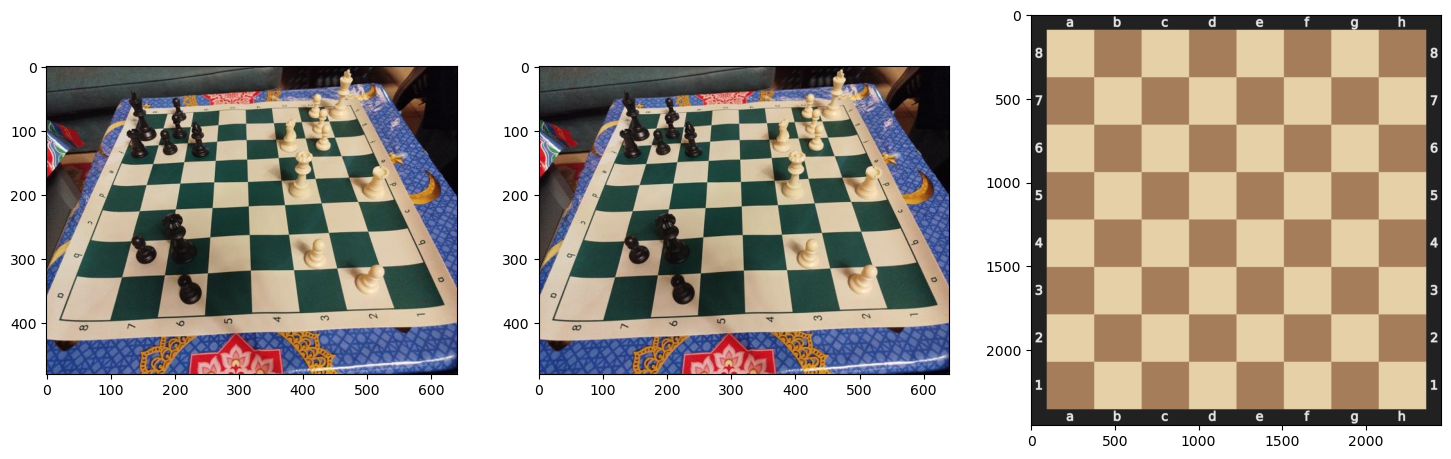

In [8]:
# for i in tqdm(range(min(len(dataset), 30))):
# for i in tqdm(range(60,len(dataset))):
if True:
    i = 1
    # try:
    X, y = dataset[i]
    X: torch.Tensor
    X = X.to(device)
    y = y["fen"]

    X = X.permute(1, 2, 0)
    fen = y

    if (X.max() <= 1):
        X = X * 255
        X = X.to(torch.uint8)

    img.load_image(X)
    img.detect_board()
    img.recognize_pieces()

    matrix = ChessUtils.ChessTensorUtils.onehot_to_int(ChessUtils.ChessTensorUtils.FENtoTensor(fen))
    err = compare_matricies(img.piece_matrix, matrix)
    print(f"Error: {err}")

    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.imshow(X);
    plt.subplot(1,3,2)
    img.preview_board();
    plt.subplot(1,3,3)
    img.save_fen_image()
    plt.imshow(plt.imread("out_fen.png"));

    errs.append(err)
    # except Exception as e:
    #     pass

    # break

In [27]:
sum(errs) / len(errs), len(errs)

(18.0, 1)

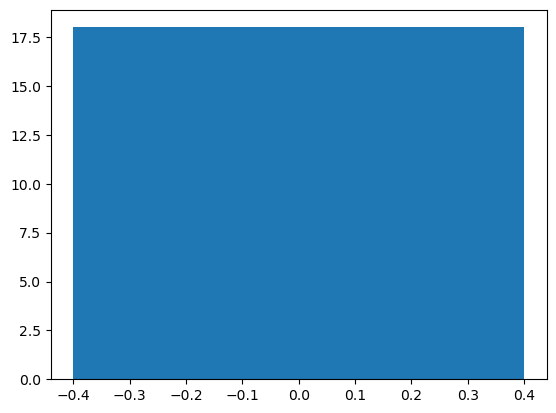

In [28]:
plt.bar(range(len(errs)), errs);

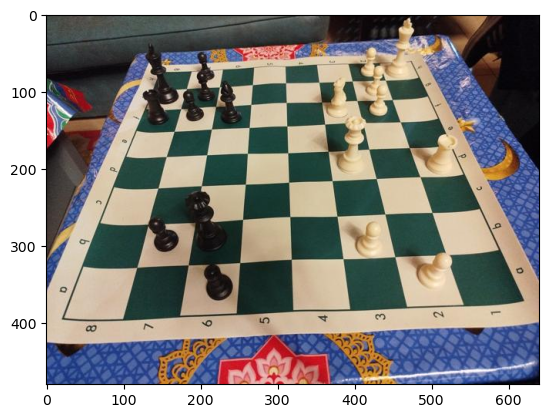

In [29]:
img.preview_board()

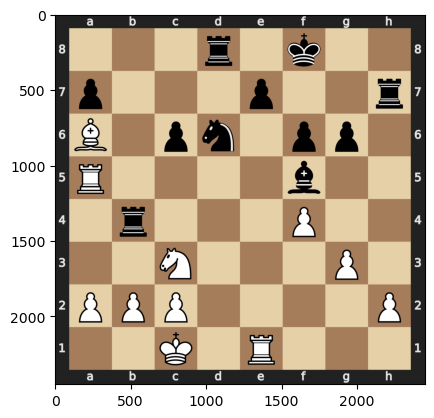

In [7]:
img.save_fen_image()
plt.imshow(plt.imread("out_fen.png"));